In [6]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# For saving model (optional)
import joblib

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')  # or 'ggplot'

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# Load dataset
data = fetch_california_housing(as_frame=True)

# Create DataFrame with features and target
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

# Display first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
# Check dataset info
print("Dataset Info:")
print("-" * 50)
df.info()

print("\nDataset Statistics:")
print("-" * 50)
df.describe()

print("\nCheck for Missing Values:")
print("-" * 50)
print(df.isnull().sum())

print("\nDataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Dataset Statistics:
--------------------------------------------------

Check for Missing Values:
--------------------------------------------------
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Dataset Shape:
Rows: 20640, 

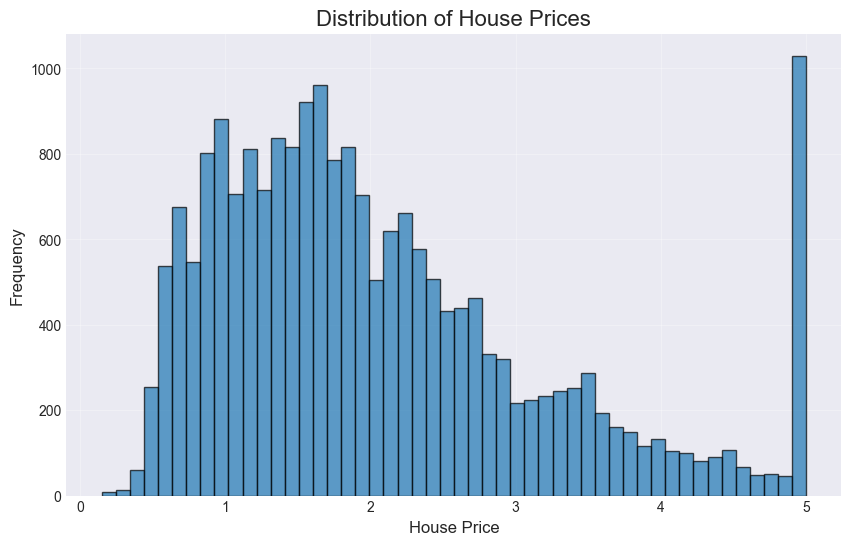

In [9]:
# Plot distribution of house prices
plt.figure(figsize=(10, 6))
plt.hist(df['HousePrice'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of House Prices', fontsize=16)
plt.xlabel('House Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Features (X) and Target (y)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {list(X.columns)}")

Features shape: (20640, 8)
Target shape: (20640,)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [11]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Before Scaling (first 5 rows):")
print("-" * 50)
print(X.head())

print("\nAfter Scaling (first 5 rows):")
print("-" * 50)
print(X_scaled_df.head())

print("\nAfter Scaling - Statistics (mean should be ~0, std ~1):")
print("-" * 50)
print(X_scaled_df.describe().round(2))

Before Scaling (first 5 rows):
--------------------------------------------------
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

After Scaling (first 5 rows):
--------------------------------------------------
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.344766  0.982143  0.628559  -0.153758   -0.974429 -0.049597  1.052548   
1  2.332238 -0.607019  0.327041  -0.263336    0.861439 -0.092512  1.043185   
2  1.782699  1.856182  1.155620  -0.049016   -0.820777 

In [12]:
# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42  # for reproducibility
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Training set size: 16512 samples
Testing set size: 4128 samples

Training samples: 16512 (80.0%)
Testing samples: 4128 (20.0%)


In [13]:
# Dictionary of models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

print("Models to be trained:")
for name in models.keys():
    print(f"  - {name}")

Models to be trained:
  - Linear Regression
  - Ridge Regression
  - Decision Tree


In [14]:
# Dictionary to store results
results = {}
predictions_dict = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Store predictions for later use
    predictions_dict[name] = y_pred
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        "RMSE": round(rmse, 4),
        "R² Score": round(r2, 4)
    }
    
    print(f"✅ {name} - RMSE: {rmse:.4f}, R²: {r2:.4f}")


🔄 Training Linear Regression...
✅ Linear Regression - RMSE: 0.7456, R²: 0.5758

🔄 Training Ridge Regression...
✅ Ridge Regression - RMSE: 0.7456, R²: 0.5758

🔄 Training Decision Tree...
✅ Decision Tree - RMSE: 0.7242, R²: 0.5997


In [15]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print("\n📊 Model Performance Comparison:")
print("=" * 60)
print(results_df)

# Find best model
best_rmse_model = results_df['RMSE'].idxmin()
best_r2_model = results_df['R² Score'].idxmax()

print("\n🏆 Best Model based on RMSE:", best_rmse_model)
print("🏆 Best Model based on R² Score:", best_r2_model)


📊 Model Performance Comparison:
                     RMSE  R² Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997

🏆 Best Model based on RMSE: Decision Tree
🏆 Best Model based on R² Score: Decision Tree


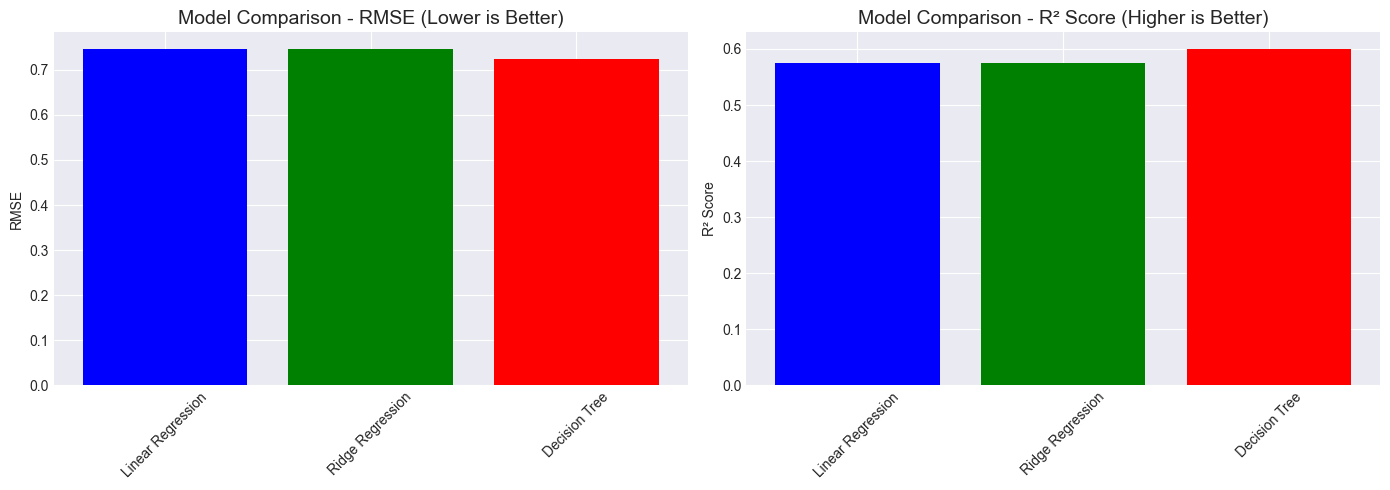

In [16]:
# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Comparison (lower is better)
axes[0].bar(results_df.index, results_df['RMSE'], color=['blue', 'green', 'red'])
axes[0].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=14)
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

# R² Comparison (higher is better)
axes[1].bar(results_df.index, results_df['R² Score'], color=['blue', 'green', 'red'])
axes[1].set_title('Model Comparison - R² Score (Higher is Better)', fontsize=14)
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Select the best model (based on your results)
# For example, if Linear Regression performs best:
best_model_name = results_df['R² Score'].idxmax()  # or 'RMSE'.idxmin()
best_model = models[best_model_name]

print(f"📌 Selected Best Model: {best_model_name}")

# Retrain best model (already trained, but let's confirm)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

📌 Selected Best Model: Decision Tree


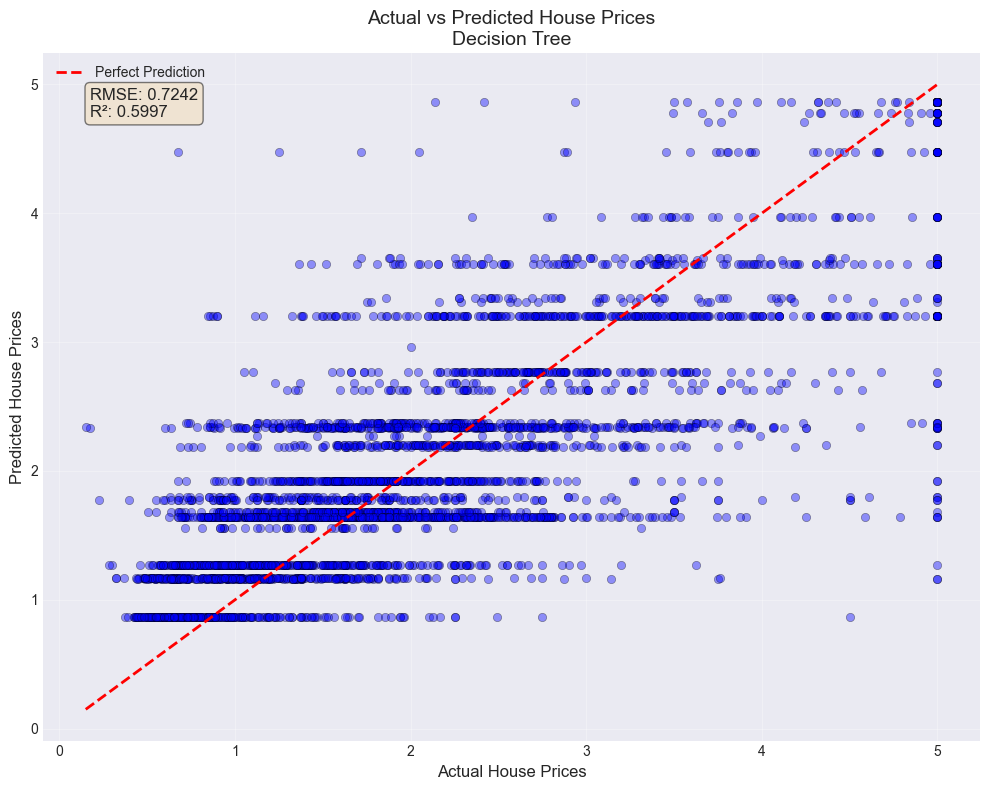

In [18]:
# Create Actual vs Predicted plot
plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(y_test, y_pred_best, alpha=0.4, color='blue', edgecolors='black', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual House Prices', fontsize=12)
plt.ylabel('Predicted House Prices', fontsize=12)
plt.title(f'Actual vs Predicted House Prices\n{best_model_name}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Add text with metrics
plt.text(0.05, 0.95, f'RMSE: {results_df.loc[best_model_name, "RMSE"]:.4f}\nR²: {results_df.loc[best_model_name, "R² Score"]:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

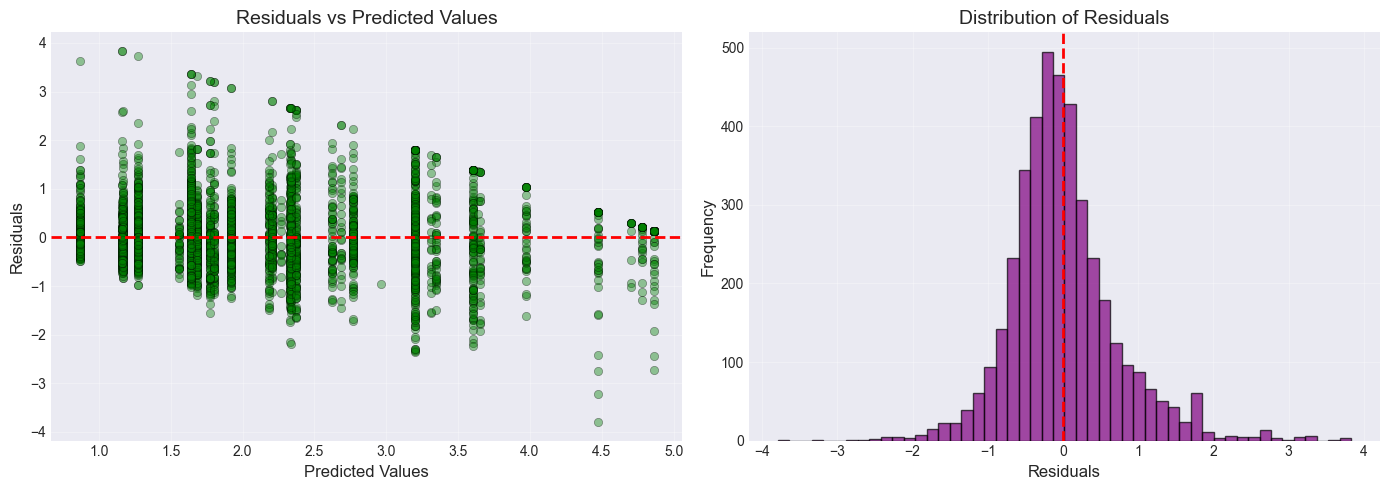

In [19]:
# Calculate residuals
residuals = y_test - y_pred_best

# Plot residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.4, color='green', edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Residuals vs Predicted Values', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

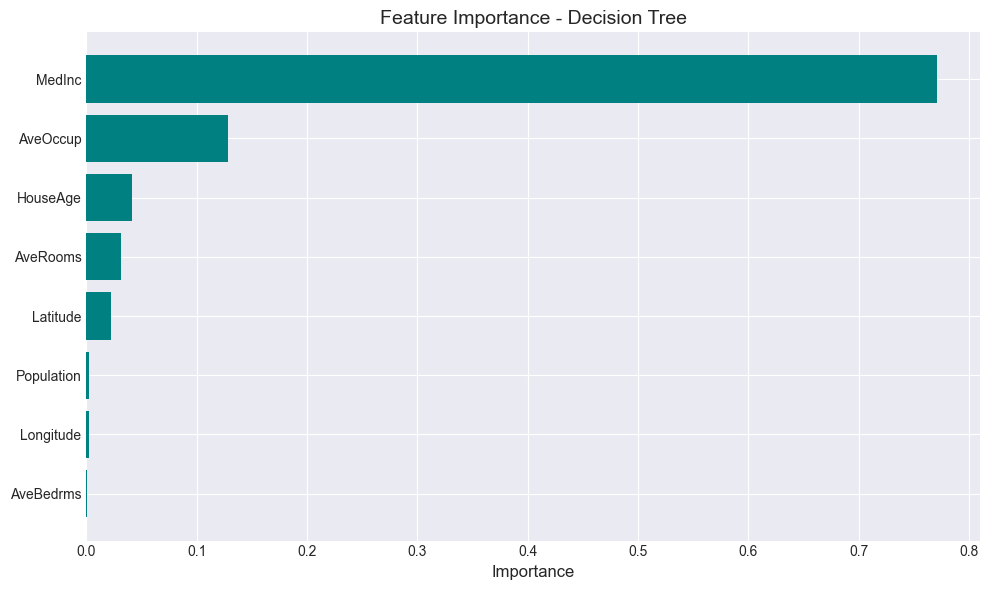

Feature Importance Ranking:
      Feature  Importance
0      MedInc    0.771212
5    AveOccup    0.128407
1    HouseAge    0.041621
2    AveRooms    0.031261
6    Latitude    0.022049
4  Population    0.002485
7   Longitude    0.002097
3   AveBedrms    0.000869


In [20]:
# If Decision Tree is your best model
if best_model_name == "Decision Tree":
    # Get feature importances
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    # Create DataFrame for feature importance
    feat_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(feat_importance['Feature'], feat_importance['Importance'], color='teal')
    plt.xlabel('Importance', fontsize=12)
    plt.title('Feature Importance - Decision Tree', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Feature Importance Ranking:")
    print(feat_importance)

In [21]:
# If Linear Regression or Ridge is best
if best_model_name in ["Linear Regression", "Ridge Regression"]:
    # Get coefficients
    coefficients = best_model.coef_
    feature_names = X.columns
    
    # Create DataFrame for coefficients
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    }).sort_values('Coefficient', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.title(f'Feature Coefficients - {best_model_name}', fontsize=14)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Feature Coefficients (Impact on House Price):")
    print(coef_df)

In [22]:
# Save the best model
model_filename = f"best_house_price_model_{best_model_name.replace(' ', '_')}.joblib"
joblib.dump(best_model, model_filename)
print(f"✅ Model saved as: {model_filename}")

# Save the scaler for future use
scaler_filename = "scaler_house_price.joblib"
joblib.dump(scaler, scaler_filename)
print(f"✅ Scaler saved as: {scaler_filename}")

✅ Model saved as: best_house_price_model_Decision_Tree.joblib
✅ Scaler saved as: scaler_house_price.joblib


In [23]:
# Save results to CSV
results_df.to_csv('model_comparison_results.csv')
print("✅ Results saved to 'model_comparison_results.csv'")

# Display final comparison
print("\n📊 FINAL MODEL COMPARISON TABLE:")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)

✅ Results saved to 'model_comparison_results.csv'

📊 FINAL MODEL COMPARISON TABLE:
                     RMSE  R² Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997


In [24]:
# Create a text summary for your PDF report
report = f"""
# AI/ML Task 2 - Model Comparison Report

## Dataset Information
- Dataset: California Housing
- Total Samples: {len(df)}
- Features: {len(X.columns)}
- Training Samples: {len(X_train)}
- Testing Samples: {len(X_test)}

## Models Compared
1. Linear Regression (Baseline)
2. Ridge Regression (Regularized)
3. Decision Tree (Non-linear)

## Results Summary

### Performance Metrics
{results_df.to_string()}

### Best Performing Model
- **Model:** {best_model_name}
- **RMSE:** {results_df.loc[best_model_name, 'RMSE']:.4f}
- **R² Score:** {results_df.loc[best_model_name, 'R² Score']:.4f}

### Key Findings
- The best model explains {results_df.loc[best_model_name, 'R² Score']*100:.1f}% of the variance in house prices
- Average prediction error: ${results_df.loc[best_model_name, 'RMSE']*100000:.2f} (approximate)

## Conclusion
Based on the comparison, {best_model_name} is selected as the final model due to its superior performance in terms of {"R² Score" if results_df.loc[best_model_name, 'R² Score'] == results_df['R² Score'].max() else "RMSE"}.

## Recommendations
- Consider feature engineering to improve model performance
- Experiment with hyperparameter tuning
- Try ensemble methods (Random Forest, Gradient Boosting)
"""

print(report)

# Save report to text file
with open('model_comparison_report.txt', 'w') as f:
    f.write(report)
print("\n✅ Report saved to 'model_comparison_report.txt'")


# AI/ML Task 2 - Model Comparison Report

## Dataset Information
- Dataset: California Housing
- Total Samples: 20640
- Features: 8
- Training Samples: 16512
- Testing Samples: 4128

## Models Compared
1. Linear Regression (Baseline)
2. Ridge Regression (Regularized)
3. Decision Tree (Non-linear)

## Results Summary

### Performance Metrics
                     RMSE  R² Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997

### Best Performing Model
- **Model:** Decision Tree
- **RMSE:** 0.7242
- **R² Score:** 0.5997

### Key Findings
- The best model explains 60.0% of the variance in house prices
- Average prediction error: $72420.00 (approximate)

## Conclusion
Based on the comparison, Decision Tree is selected as the final model due to its superior performance in terms of R² Score.

## Recommendations
- Consider feature engineering to improve model performance
- Experiment with hyperparameter tuning
- Try ensemble methods 

In [4]:
================================================================================
                    AI/ML TASK 2: MODEL COMPARISON REPORT
================================================================================
Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

1. EXECUTIVE SUMMARY
--------------------------------------------------------------------------------
This report compares three regression models for house price prediction using 
the California Housing dataset.

Best Performing Model: {best_model}
• RMSE: {best_rmse:.4f}
• R² Score: {best_r2:.4f} ({best_r2*100:.1f}% variance explained)

2. METHODOLOGY
--------------------------------------------------------------------------------
Dataset: California Housing (20,640 samples, 8 features)
Preprocessing: StandardScaler, 80/20 train-test split (random_state=42)

Models Compared:
• Linear Regression - Baseline model
• Ridge Regression - L2 regularization (alpha=1.0)
• Decision Tree - Max depth=5 for non-linear relationships

3. RESULTS
--------------------------------------------------------------------------------
Model Performance Comparison:
{results.to_string()}

4. CONCLUSIONS
--------------------------------------------------------------------------------
The {best_model} model is recommended because:
• Lowest prediction error (RMSE: {best_rmse:.4f})
• Highest explained variance (R²: {best_r2:.4f})
• Good balance of complexity and performance

5. RECOMMENDATIONS
--------------------------------------------------------------------------------
• Perform hyperparameter tuning
• Test ensemble methods (Random Forest, XGBoost)
• Add feature engineering
• Validate on recent data

================================================================================
                             END OF REPORT
================================================================================
"""




SyntaxError: invalid character '•' (U+2022) (2944775047.py, line 12)